Deep Dive on certain high impact/volatile players to see if any inverse correlators exist within a subset of the players. It's possible this subset is masked/lost when looking at the population as a whole.

In [61]:
# Libraries
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [84]:
# Taken from Ani's implementation in player_level_twitter_correlation_analysis.py
def dcor(a, b):
    def cent_dist(v):
        d = np.abs(v[:, None] - v[None, :]).astype(float)
        return d - d.mean(1, keepdims=True) - d.mean(0, keepdims=True) + d.mean()
    A, B = cent_dist(a), cent_dist(b)
    denom = np.sqrt(abs((A * A).mean()) * abs((B * B).mean()))
    return np.sqrt(abs((A * B).mean()) / denom) if denom > 0 else 0.0

def correlate_series(xi, yi, min_n=10):
    """Return dict of correlation stats, or None if insufficient data."""
    mask = ~(np.isnan(xi) | np.isnan(yi))
    xi, yi = xi[mask], yi[mask]
    if len(xi) < min_n:
        return None
    r_p, p_p = stats.pearsonr(xi, yi)
    r_s, p_s = stats.spearmanr(xi, yi)
    dc       = dcor(xi, yi)
    return dict(
        n           = len(xi),
        pearson_r   = round(r_p, 4), pearson_p  = round(p_p, 4),
        spearman_r  = round(r_s, 4), spearman_p = round(p_s, 4),
        distance_cor= round(dc,  4),
        pearson_sig = "***" if p_p<0.001 else ("**" if p_p<0.01 else ("*" if p_p<0.05 else "")),
        spearman_sig= "***" if p_s<0.001 else ("**" if p_s<0.01 else ("*" if p_s<0.05 else "")),
    )

In [63]:
# Filter to players of interest
players = ['Jalen Hurts', 'A.J. Brown', 'Josh Allen', 'Baker Mayfield', 'Ja\'Marr Chase', 'George Pickens']

sentiment_df = pd.read_csv('sentiment_indices/twitter_local_index_sprint2.csv')
sentiment_df['subject'] = sentiment_df['subject'].replace({'AJ Brown': 'A.J. Brown',
                                                           'JaMarr Chase': 'Ja\'Marr Chase'})
stats_df = pd.read_csv('data/nfl_sentiment_2025_cleaned.csv')

sentiment_df = sentiment_df[sentiment_df['subject'].isin(players)]
stats_df = stats_df[stats_df['player_name'].isin(players)]

sentiment_df['game_id'] = sentiment_df.apply(
        lambda x: int(x['game_id'][1:]), axis=1
)


qb_cols = [
    'game_week',
    'stats_passing_pass_attempts',
    'stats_passing_pass_completions',
    'stats_passing_pass_yards',
    'stats_passing_pass_td',
    'stats_passing_pass_int',
    'stats_passing_qb_rating'
]

wr_cols = [
    'game_week',
    'stats_receiving_targets',
    'stats_receiving_receptions',
    'stats_receiving_rec_yards',
    'stats_receiving_rec_td'
]

qb_stats_list = ['Pass Attempts', 'Completions', 'Pass Yards', 'Pass TDs', 'INTs', 'QB Rating']
wr_stats_list = ['Targets', 'Receptions', 'Rec Yards', ' Rec TDs']

In [64]:
def get_dfs_for_player(player_name, cols):
    player_sent_df = sentiment_df[sentiment_df['subject'] == player_name]
    player_perf_df = stats_df[stats_df['player_name'] == player_name]
    player_perf_df = player_perf_df[cols]
    player_perf_df = player_perf_df[player_perf_df['game_week'] < 19]
    return player_sent_df.sort_values(by='game_id'), player_perf_df.sort_values(by='game_week')

def standardize_cols(sent_df, perf_df, cols):
    sent_df['local_index'] = (sent_df['local_index'] - np.mean(sent_df['local_index'])) / np.std(sent_df['local_index'])

    for col in cols:
        if col != 'game_week':
            perf_df[col] = (perf_df[col] - np.mean(perf_df[col])) / np.std(perf_df[col])

    return sent_df, perf_df

def make_plot(std_sent_df, std_perf_df, player_name):
    plt.plot(std_sent_df['game_id'], std_sent_df['local_index'], label='Sentiment')
    for col in std_perf_df.columns:
        if col != 'game_week':
            parts = col.split('_')[2:]
            lab = ''
            for s in parts:
                lab += s.capitalize() + ' '
            plt.plot(std_perf_df['game_week'], std_perf_df[col], alpha = 0.5, label=lab.strip())

    plt.xlabel('Week')
    plt.ylabel('Standardized Metric Value')
    plt.title(player_name + ' Standardized Sentiment and Performance Metrics')
    plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])
    plt.legend()
    plt.show()

def get_corr_df(sent_df, perf_df, df_cols, col_labels):
    df_cols.remove('game_week')
    dicts = [correlate_series(sent_df['local_index'].values.astype(float), perf_df[col].values.astype(float)) for col in df_cols]
    corr_df = pd.DataFrame({
        'Statistic': col_labels,
        'Pearson': [d['pearson_r'] for d in dicts],
        'Spearman': [d['spearman_r'] for d in dicts],
        'Distance': [d['distance_cor'] for d in dicts]
    })
    return corr_df

def make_lagged_plot(std_sent_lag_df, std_perf_lag_df, player_name):
    std_perf_lag_df['game_week'] -= 1
    plt.plot(std_sent_lag_df['game_id'], std_sent_lag_df['local_index'], label='Sentiment')
    for col in std_perf_lag_df.columns:
        if col != 'game_week':
            parts = col.split('_')[2:]
            lab = ''
            for s in parts:
                lab += s.capitalize() + ' '
            plt.plot(std_perf_lag_df['game_week'], std_perf_lag_df[col], alpha = 0.5, label=lab.strip())

    plt.xlabel('Week Sentiment / Week + 1 Performance')
    plt.ylabel('Standardized Metric Value')
    plt.title(player_name + ' Std. Sentiment and Lagged Performance')
    plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17])
    plt.legend()
    plt.show()

# Jalen Hurts

In [65]:
hurts_sent_df, hurts_perf_df = get_dfs_for_player('Jalen Hurts', qb_cols)
hurts_sent_df = hurts_sent_df[hurts_sent_df['game_id'] != 18]   # Hurts did not play W18
hurts_perf_df.head()

,game_week,stats_passing_pass_attempts,stats_passing_pass_completions,stats_passing_pass_yards,stats_passing_pass_td,stats_passing_pass_int,stats_passing_qb_rating
28,1,23,19,152,0,0,94.2
2665,2,22,15,101,0,0,78.0
3391,3,32,21,226,3,0,117.4
4946,4,24,15,130,2,0,104.5
6408,5,38,23,280,2,0,100.8


In [66]:
hurts_sent_df_std, hurts_perf_df_std = standardize_cols(hurts_sent_df, hurts_perf_df, qb_cols)

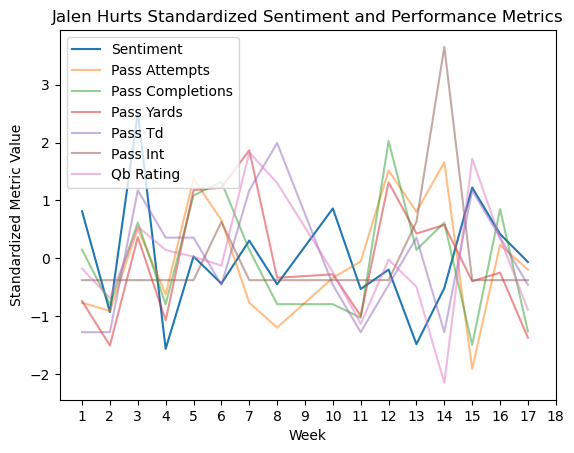

In [67]:
make_plot(hurts_sent_df_std, hurts_perf_df_std, 'Jalen Hurts')

Overall, looks like a somewhat positive correlation

In [68]:
hurts_corr_df = get_corr_df(hurts_sent_df, hurts_perf_df, qb_cols.copy(), qb_stats_list)
hurts_corr_df

,Statistic,Pearson,Spearman,Distance
0,Pass Attempts,-0.1421,-0.1589,0.3621
1,Completions,0.0654,0.0758,0.3275
2,Pass Yards,0.1393,0.1971,0.3782
3,Pass TDs,0.2713,0.3018,0.4394
4,INTs,-0.2507,-0.3954,0.3834
5,QB Rating,0.3894,0.4618,0.4967


## Lagged Performance

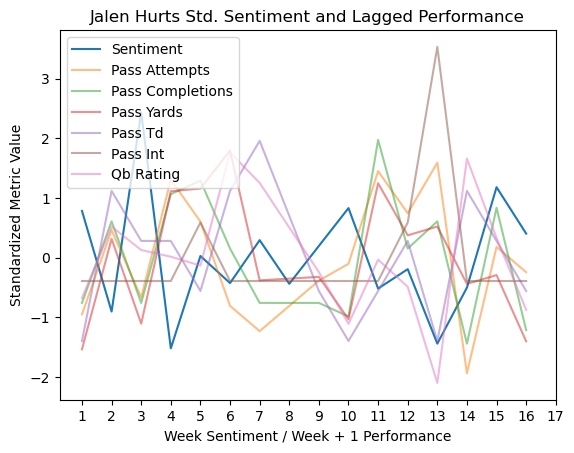

In [69]:
# Remove last row of sentiment and first row of performance
hurts_sent_lag = hurts_sent_df.iloc[:-1]
hurts_perf_lag = hurts_perf_df.iloc[1:]
hurts_sent_lag_std, hurts_perf_lag_std = standardize_cols(hurts_sent_lag, hurts_perf_lag, qb_cols)
make_lagged_plot(hurts_sent_lag_std, hurts_perf_lag_std, 'Jalen Hurts')

In [70]:
hurts_corr_lag = get_corr_df(hurts_sent_lag, hurts_perf_lag, qb_cols.copy(), qb_stats_list)
hurts_corr_lag

,Statistic,Pearson,Spearman,Distance
0,Pass Attempts,-0.4527,-0.4607,0.5849
1,Completions,-0.4032,-0.3989,0.5145
2,Pass Yards,-0.6392,-0.6107,0.7082
3,Pass TDs,-0.0593,-0.1282,0.3570
4,INTs,-0.3879,-0.2251,0.4388
5,QB Rating,0.0283,-0.0929,0.4052


# Josh Allen

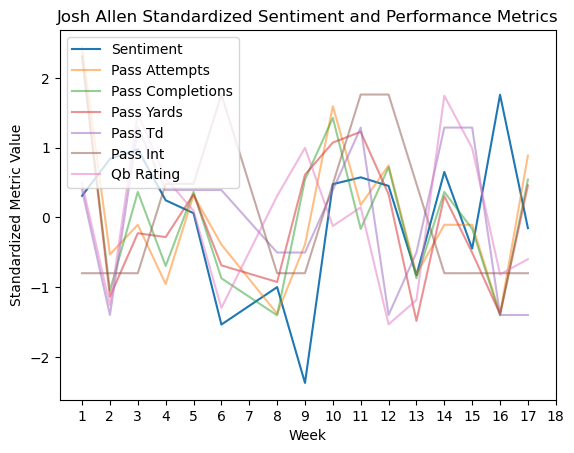

In [71]:
allen_sent_df, allen_perf_df = get_dfs_for_player('Josh Allen', qb_cols)
allen_sent_df = allen_sent_df[allen_sent_df['game_id'] != 18]   # Allen also did not play W18
allen_sent_df_std, allen_perf_df_std = standardize_cols(allen_sent_df, allen_perf_df, qb_cols)
make_plot(allen_sent_df_std, allen_perf_df_std, 'Josh Allen')

In [72]:
allen_corr_df = get_corr_df(allen_sent_df, allen_perf_df, qb_cols.copy(), qb_stats_list)
allen_corr_df

,Statistic,Pearson,Spearman,Distance
0,Pass Attempts,0.1364,0.1123,0.4661
1,Completions,0.0560,0.0104,0.4045
2,Pass Yards,0.0332,0.0250,0.4435
3,Pass TDs,0.0096,0.0897,0.4102
4,INTs,-0.0857,-0.1346,0.2621
5,QB Rating,-0.0201,0.0294,0.3101


## Lagged Performance

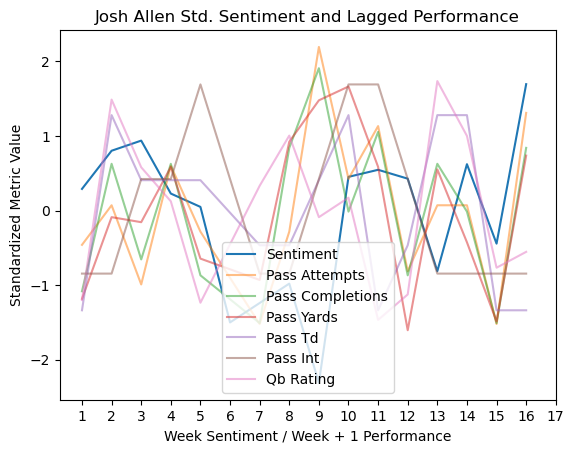

In [73]:
# Remove last row of sentiment and first row of performance
allen_sent_lag = allen_sent_df.iloc[:-1]
allen_perf_lag = allen_perf_df.iloc[1:]
allen_sent_lag_std, allen_perf_lag_std = standardize_cols(allen_sent_lag, allen_perf_lag, qb_cols)
make_lagged_plot(allen_sent_lag_std, allen_perf_lag_std, 'Josh Allen')

In [74]:
allen_corr_lag = get_corr_df(allen_sent_lag, allen_perf_lag, qb_cols.copy(), qb_stats_list)
allen_corr_lag

,Statistic,Pearson,Spearman,Distance
0,Pass Attempts,-0.0034,0.1795,0.4659
1,Completions,-0.1014,0.0899,0.4223
2,Pass Yards,-0.1200,0.0107,0.3667
3,Pass TDs,-0.0616,0.0516,0.2999
4,INTs,0.1161,0.0885,0.3509
5,QB Rating,-0.1673,-0.0357,0.3865


# Baker Mayfield

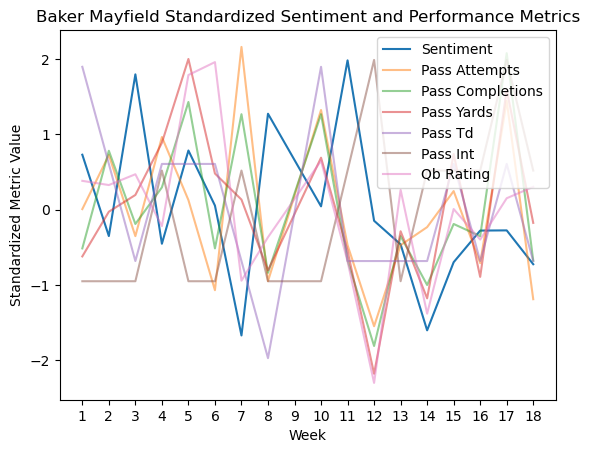

In [75]:
mayfield_sent_df, mayfield_perf_df = get_dfs_for_player('Baker Mayfield', qb_cols)
mayfield_sent_df_std, mayfield_perf_df_std = standardize_cols(mayfield_sent_df, mayfield_perf_df, qb_cols)
make_plot(mayfield_sent_df_std, mayfield_perf_df_std, 'Baker Mayfield')

In [76]:
mayfield_corr_df = get_corr_df(mayfield_sent_df, mayfield_perf_df, qb_cols.copy(), qb_stats_list)
mayfield_corr_df

,Statistic,Pearson,Spearman,Distance
0,Pass Attempts,-0.3328,-0.2526,0.4125
1,Completions,-0.1362,-0.0762,0.2893
2,Pass Yards,0.0330,0.0270,0.3192
3,Pass TDs,-0.0505,0.0663,0.4008
4,INTs,-0.3706,-0.4123,0.5096
5,QB Rating,0.2742,0.3578,0.4548


## Lagged Performance

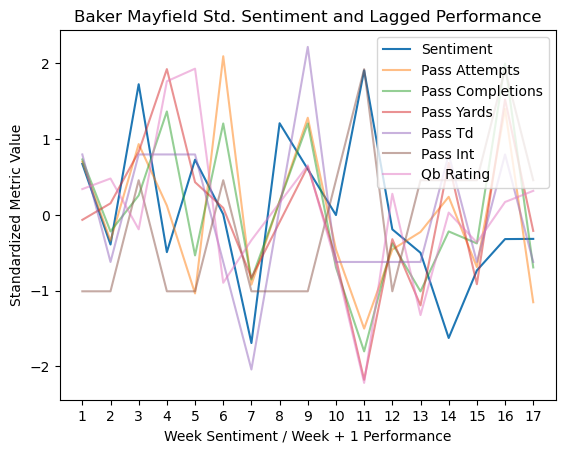

In [77]:
# Remove last row of sentiment and first row of performance
mayfield_sent_lag = mayfield_sent_df.iloc[:-1]
mayfield_perf_lag = mayfield_perf_df.iloc[1:]
mayfield_sent_lag_std, mayfield_perf_lag_std = standardize_cols(mayfield_sent_lag, mayfield_perf_lag, qb_cols)
make_lagged_plot(mayfield_sent_lag_std, mayfield_perf_lag_std, 'Baker Mayfield')

In [78]:
mayfield_corr_lag = get_corr_df(mayfield_sent_lag, mayfield_perf_lag, qb_cols.copy(), qb_stats_list)
mayfield_corr_lag

,Statistic,Pearson,Spearman,Distance
0,Pass Attempts,0.1189,0.0868,0.3976
1,Completions,0.0139,0.0870,0.3636
2,Pass Yards,-0.0927,0.0824,0.3918
3,Pass TDs,0.4266,0.3643,0.4561
4,INTs,0.1596,0.0757,0.2826
5,QB Rating,-0.1225,0.0735,0.3952


# AJ Brown

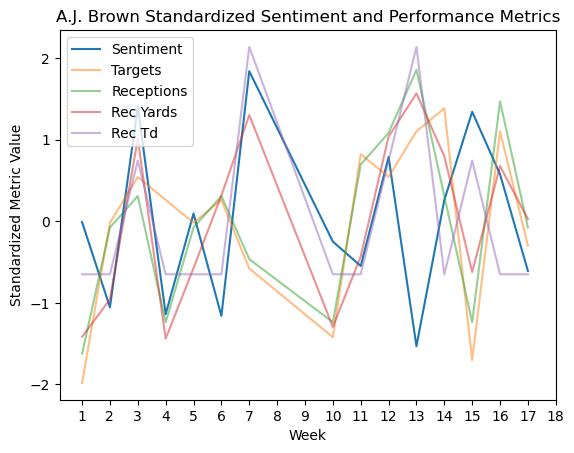

In [80]:
brown_sent_df, brown_perf_df = get_dfs_for_player('A.J. Brown', wr_cols)
brown_sent_df = brown_sent_df[~brown_sent_df['game_id'].isin([8, 18])]   # Eagles rested starters in W18, Brown injured W8
brown_sent_df_std, brown_perf_df_std = standardize_cols(brown_sent_df, brown_perf_df, wr_cols)
make_plot(brown_sent_df_std, brown_perf_df_std, 'A.J. Brown')

In [81]:
brown_corr_df = get_corr_df(brown_sent_df, brown_perf_df, wr_cols.copy(), wr_stats_list)
brown_corr_df

,Statistic,Pearson,Spearman,Distance
0,Targets,-0.2220,-0.1290,0.3744
1,Receptions,-0.1351,-0.0903,0.2986
2,Rec Yards,0.3185,0.3000,0.4846
3,Rec TDs,0.3849,0.4173,0.6184


## Lagged Performance

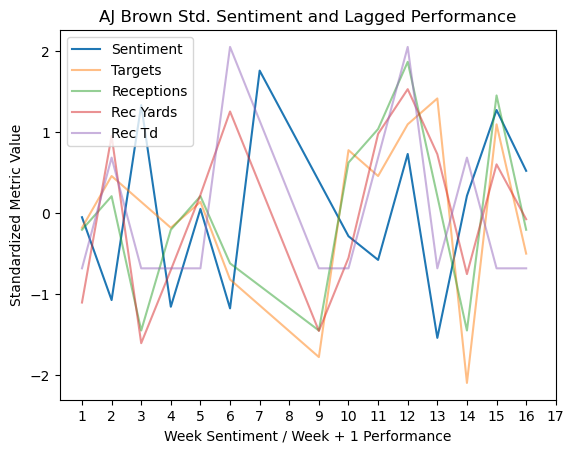

In [82]:
# Remove last row of sentiment and first row of performance
brown_sent_lag = brown_sent_df.iloc[:-1]
brown_perf_lag = brown_perf_df.iloc[1:]
brown_sent_lag_std, brown_perf_lag_std = standardize_cols(brown_sent_lag, brown_perf_lag, wr_cols)
make_lagged_plot(brown_sent_lag_std, brown_perf_lag_std, 'AJ Brown')

In [85]:
brown_corr_lag = get_corr_df(brown_sent_lag, brown_perf_lag, wr_cols.copy(), wr_stats_list)
brown_corr_lag

,Statistic,Pearson,Spearman,Distance
0,Targets,-0.2444,-0.1722,0.3672
1,Receptions,-0.1444,-0.1537,0.4977
2,Rec Yards,-0.4400,-0.4505,0.4923
3,Rec TDs,-0.2284,-0.2271,0.3185


# Ja'Marr Chase

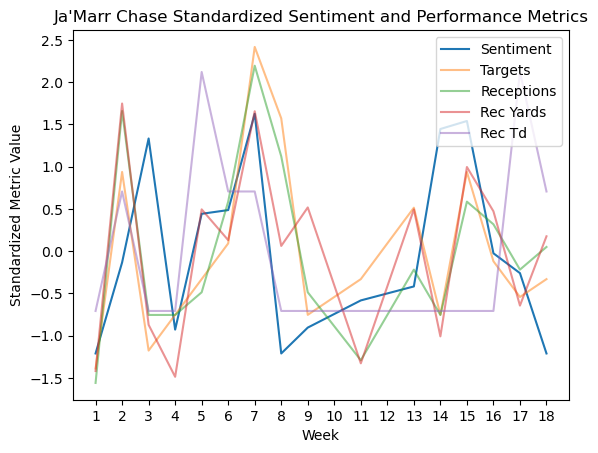

In [87]:
chase_sent_df, chase_perf_df = get_dfs_for_player('Ja\'Marr Chase', wr_cols)
chase_sent_df = chase_sent_df[chase_sent_df['game_id'] != 12]   # Chase injured in W12
chase_sent_df_std, chase_perf_df_std = standardize_cols(chase_sent_df, chase_perf_df, wr_cols)
make_plot(chase_sent_df_std, chase_perf_df_std, 'Ja\'Marr Chase')

In [88]:
chase_corr_df = get_corr_df(chase_sent_df, chase_perf_df, wr_cols.copy(), wr_stats_list)
chase_corr_df

,Statistic,Pearson,Spearman,Distance
0,Targets,0.2607,0.2673,0.3501
1,Receptions,0.2953,0.2965,0.3558
2,Rec Yards,0.2950,0.3926,0.3793
3,Rec TDs,0.1005,0.1885,0.2848


## Lagged Performance

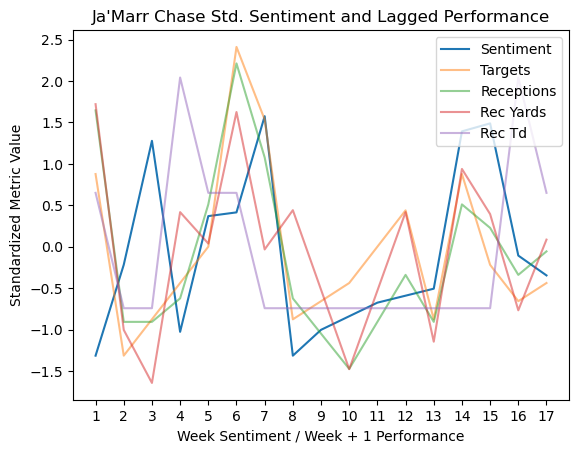

In [89]:
# Remove last row of sentiment and first row of performance
chase_sent_lag = chase_sent_df.iloc[:-1]
chase_perf_lag = chase_perf_df.iloc[1:]
chase_sent_lag_std, chase_perf_lag_std = standardize_cols(chase_sent_lag, chase_perf_lag, wr_cols)
make_lagged_plot(chase_sent_lag_std, chase_perf_lag_std, 'Ja\'Marr Chase')

In [90]:
chase_corr_lag = get_corr_df(chase_sent_lag, chase_perf_lag, wr_cols.copy(), wr_stats_list)
chase_corr_lag

,Statistic,Pearson,Spearman,Distance
0,Targets,0.3160,0.3126,0.4096
1,Receptions,0.2944,0.3606,0.4814
2,Rec Yards,-0.0527,-0.1986,0.2952
3,Rec TDs,-0.2925,-0.2216,0.3685


# George Pickens

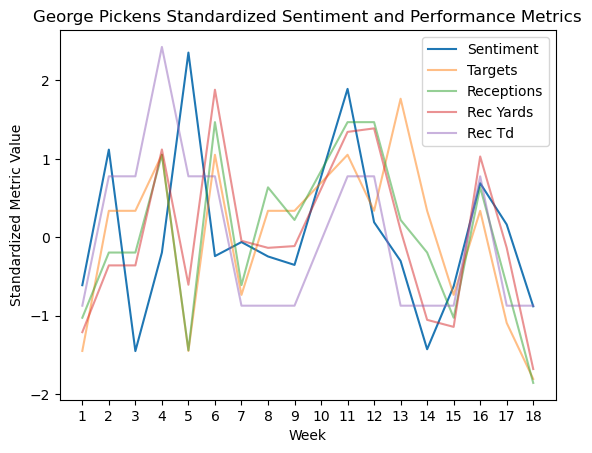

In [92]:
pickens_sent_df, pickens_perf_df = get_dfs_for_player('George Pickens', wr_cols)
# chase_sent_df = chase_sent_df[chase_sent_df['game_id'] != 12]   # Chase injured in W12
pickens_sent_df_std, pickens_perf_df_std = standardize_cols(pickens_sent_df, pickens_perf_df, wr_cols)
make_plot(pickens_sent_df_std, pickens_perf_df_std, 'George Pickens')

In [93]:
pickens_corr_df = get_corr_df(pickens_sent_df, pickens_perf_df, wr_cols.copy(), wr_stats_list)
pickens_corr_df

,Statistic,Pearson,Spearman,Distance
0,Targets,-0.0065,0.1160,0.3047
1,Receptions,0.1431,0.3000,0.4059
2,Rec Yards,0.3538,0.4982,0.5052
3,Rec TDs,0.4039,0.5203,0.5581


## Lagged Performance

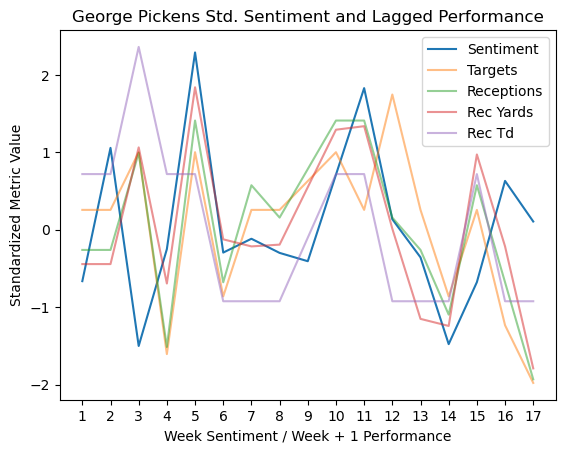

In [94]:
# Remove last row of sentiment and first row of performance
pickens_sent_lag = pickens_sent_df.iloc[:-1]
pickens_perf_lag = pickens_perf_df.iloc[1:]
pickens_sent_lag_std, pickens_perf_lag_std = standardize_cols(pickens_sent_lag, pickens_perf_lag, wr_cols)
make_lagged_plot(pickens_sent_lag_std, pickens_perf_lag_std, 'George Pickens')

In [95]:
pickens_corr_lag = get_corr_df(pickens_sent_lag, pickens_perf_lag, wr_cols.copy(), wr_stats_list)
pickens_corr_lag

,Statistic,Pearson,Spearman,Distance
0,Targets,0.1097,-0.0370,0.2958
1,Receptions,0.3009,0.0726,0.4446
2,Rec Yards,0.3696,0.1753,0.4866
3,Rec TDs,0.0177,-0.1238,0.4210
